<a href="https://colab.research.google.com/github/peperjet/deep-learning/blob/main/Multilayer_Perceptron/7_2_activation_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

1. 계단함수 Step Function

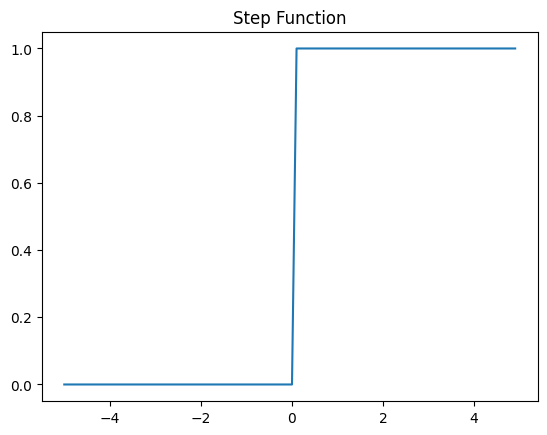

In [3]:
def step(x):
    return (x > 0).astype(int)

# -5.0부터 5.0까지 0.1 간격 생성
x = np.arange(-5.0, 5.0, 0.1)
y = step(x)
plt.title('Step Function')
plt.plot(x,y)
plt.show()

외식 결정 신경망

In [4]:
def step_function(x):
  return (x > 0).astype(int)

def decide_dining_out(hunger, fridge_empty, lazy):
  # 1. 입력 데이터 (배고픔, 냉장고 상태, 귀찮음)
  x = np.array([hunger, fridge_empty, lazy])

  # 2. 가중치 (나에게 어떤 게 더 중요한지 결정)
  # 귀찮음 (0.6) > 냉장고 상태(0.3) > 배고픔(0.2) 순으로 중요하다
  w = np.array([0.2, 0.3, 0.6])

  # 3. 편향 (외식에 대한 심리적 문턱)
  # -5.0 이면 웬만큼 조건이 맞지 않으면 외식을 안하겠다는 뜻
  b = -5.0

  # 4. 연산 (선형 결함 + 활성화 함수)
  tmp = np.sum(w * x) + b
  result = step_function(tmp)

  return "오늘 외식 합시다!" if result == 1 else "오늘 외식 안합시다...집밥 먹자"


#테스트 : (배고픔 8, 냉장고 9, 귀찮음 9) 일 때
print(decide_dining_out(8, 9, 9))


오늘 외식 합시다!


- 배고픔: $8 \times 0.2 = 1.6$
- 냉장고 상태: $9 \times 0.3 = 2.7$
- 귀찮음: $9 \times 0.6 = 5.4$
- 가중치 합계: $1.6 + 2.7 + 5.4 = 9.7$

- 최종 합계(tmp): $9.7 - 5.0 =$ $4.7$
- :step_function은 값이 0보다 크면 1(True), **0 이하이면 0(False)**
- $4.7 > 0$ 이므로 결과는 1이 됩니다.
- 따라서 result == 1 조건에 따라 "오늘 외식 합시다!"가 출력된 것입니다.

2. Sigmoid 활성화 함수

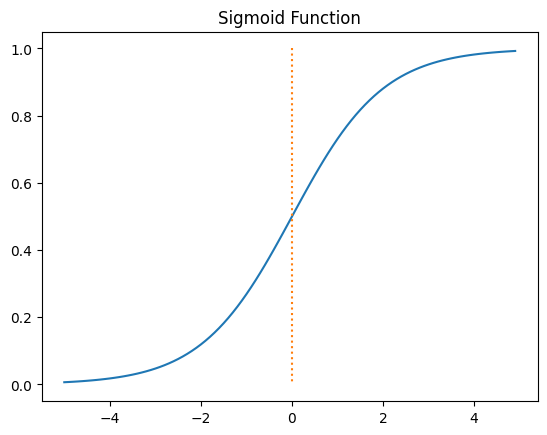

In [5]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)

plt.plot(x, y)

# 가운데 점선 추가
plt.plot([0,0],[1.0,0.0], ':')
plt.title('Sigmoid Function')
plt.show()

외식 확률 계산

In [6]:
from IPython.core.interactiveshell import ProvisionalWarning
def decide_dining_out_prob(hunger, fridge_empty, lazy):
    x = np.array([hunger, fridge_empty, lazy])
    w = np.array([0.2, 0.3, 0.6])
    b = -5.0

    tmp = np.sum(w * x) + b
    # 계단 함수 대신 시그모이드 사용
    probability = sigmoid(tmp)

    print(f"계산된 점수(tmp): {tmp:.2f}")
    print(f"외식할 확률: {probability * 100:.2f}%")

    if probability > 0.5:
      return "외식할 가능성이 높네요!"
    else:
      return "집밥 먹을 가능성이 높아요."

# 테스트 : 아까와 같은 조건 (8, 9, 9)
print(decide_dining_out_prob(8, 9, 9))

계산된 점수(tmp): 4.70
외식할 확률: 99.10%
외식할 가능성이 높네요!


- 시그모이드는 4.7이라는 숫자를 0과 1 사이의 값으로 구부려 줍니다.
- 만약 tmp가 0이라면 확률은 정확히 50%(0.5)가 나옵니다
- tmp가 지금처럼 4.7로 꽤 큰 양수라면 시그모이드 그래프상에서 오른쪽 높은 곳에 위치하게 되어 99% 높은 확률이 나옵니다

--- 상세 계산 리포트 ---
1. 가중치와 입력의 곱 합계: 9.70
2. 편향(b) 반영 최종 점수(tmp): 4.70
3. 시그모이드 통과 후 외식 확률: 99.10%
------------------------


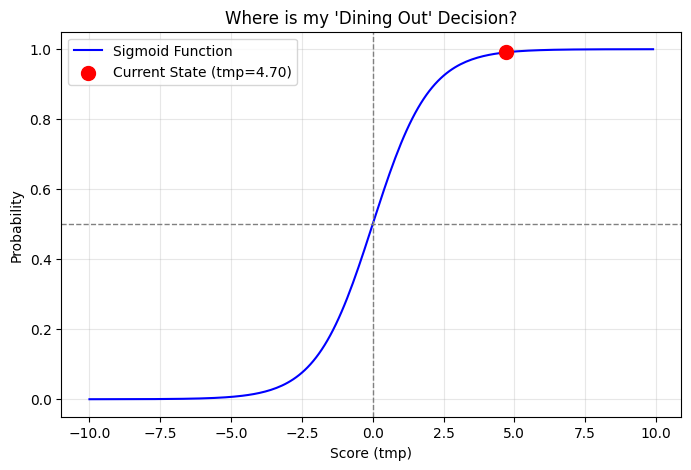

결과: 외식 합시다!


In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def decide_dining_out_visual(hunger, fridge_empty, lazy):
    # 1. 입력 및 가중치 설정
    x = np.array([hunger, fridge_empty, lazy])
    w = np.array([0.2, 0.3, 0.6])
    b = -5.0

    # 2. 상세 계산 과정 출력 (Print)
    weighted_sum = np.sum(w * x)
    tmp = weighted_sum + b
    probability = sigmoid(tmp)

    print("--- 상세 계산 리포트 ---")
    print(f"1. 가중치와 입력의 곱 합계: {weighted_sum:.2f}")
    print(f"2. 편향(b) 반영 최종 점수(tmp): {tmp:.2f}")
    print(f"3. 시그모이드 통과 후 외식 확률: {probability * 100:.2f}%")
    print("------------------------")

    # 3. 그래프 시각화 (Plot)
    x_range = np.arange(-10, 10, 0.1)
    y_range = sigmoid(x_range)

    plt.figure(figsize=(8, 5))
    plt.plot(x_range, y_range, label='Sigmoid Function', color='blue')

    # 계산된 tmp 위치에 빨간 점 찍기
    plt.scatter([tmp], [probability], color='red', s=100, zorder=5, label=f'Current State (tmp={tmp:.2f})')
    plt.axvline(0, color='gray', linestyle='--', linewidth=1) # 기준선
    plt.axhline(0.5, color='gray', linestyle='--', linewidth=1) # 50% 확률선

    plt.title("Where is my 'Dining Out' Decision?")
    plt.xlabel("Score (tmp)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return "결과: 외식 합시다!" if probability > 0.5 else "결과: 집밥 먹읍시다."

# 실행
print(decide_dining_out_visual(8, 9, 9))

3. 하이퍼볼릭 탄젠트 (tanh)
- 시그모이드와 비슷한 S자 모양이지만, 범위가 -1에서 1 사이 입니다.
- 싫으면 음수(-1), 좋으면 양수(1)로 표현합니다.
- 데이터의 중심이 0이라서 시그모이드보다 학습속도가 빠릅니다.

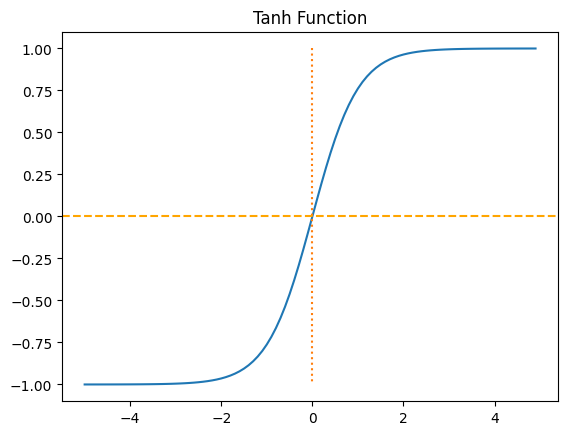

In [8]:
# -5.0부터 5.0까지 0.1 간격 생성
x = np.arange(-5.0, 5.0, 0.1)
y = np.tanh(x)

plt.plot(x, y)
plt.plot([0,0],[1.0,-1.0], ':')
plt.axhline(y=0, color='orange', linestyle='--')
plt.title('Tanh Function')
plt.show()

4. ReLU(Rectified Linear Unit)
- 0보다 작으면 무조건 0,0 보다 크면 그 값 그대로 보내기
- 계산이 간단해서 딥러닝에서 많이 쓰이는 최애 함수

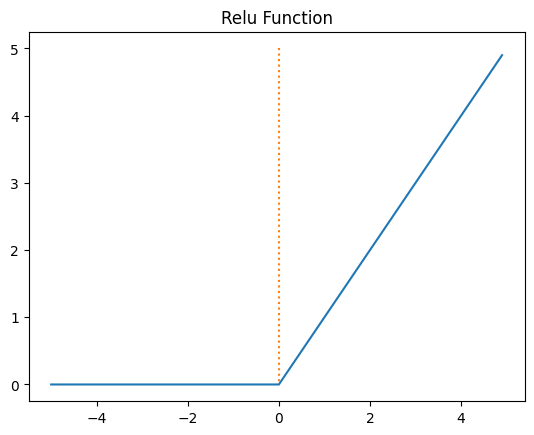

In [9]:
def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)

plt.plot(x, y)
plt.plot([0,0],[5.0,0.0], ':')
plt.title('Relu Function')
plt.show()

5. Leaky ReLU
- ReLU와 비슷하지만 0보다 작을 때 0이아닌 아주 작은 값(0.1x)을 흘려보냅니다.
- 약간의 가능성(0.1)을 열어둔 것

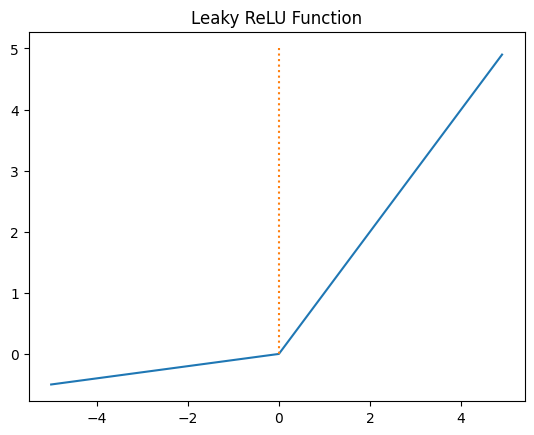

In [10]:
a = 0.1

def leaky_relu(x):
    return np.maximum(a*x, x)

x = np.arange(-5.0, 5.0, 0.1)
y = leaky_relu(x)

plt.plot(x, y)
plt.plot([0,0],[5.0,0.0], ':')
plt.title('Leaky ReLU Function')
plt.show()

6. Softmax(소프트맥스)
- 모든 출력값이 합이 1(100%)이 되도록 만듭니다.
- 모든 선택지의 점수를 모아 각각의 결론을 내줍니다
- 신경망의 마지막 단계(출력층)에서 사용합니다.

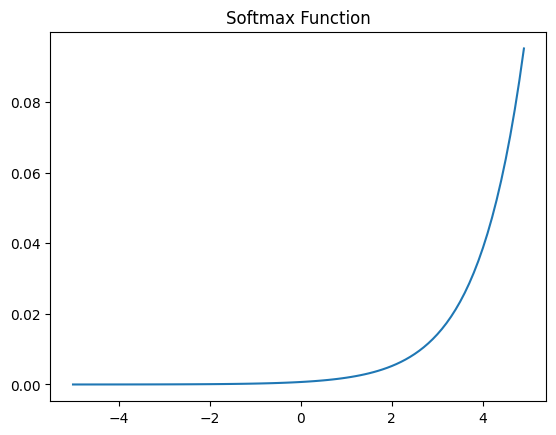

In [11]:
x = np.arange(-5.0, 5.0, 0.1) # -5.0부터 5.0까지 0.1 간격 생성
y = np.exp(x) / np.sum(np.exp(x))

plt.plot(x, y)
plt.title('Softmax Function')
plt.show()

단층 퍼셉트론으로 AND연산 (둘 다 1일 때에만 1 출력)만들기

In [12]:
def AND_gate(x1, x2):
  x = np.array([x1, x2])
  w = np.array([0.5, 0.5]) # 가중치
  b = -0.7  # 편향 (기준치)

  tmp = np.sum(w * x) + b
  if tmp <= 0:
    return 0
  else:
    return 1

# 테스트
print(AND_gate(0,0)) # 0 출력
print(AND_gate(1,1)) # 1 출력

0
1
